In [3]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow version: 2.21.0
Libraries imported successfully!


## Load our dataset

In [4]:
df = pd.read_csv(
    "learntwin_student_interactions.csv"
)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (10000, 10)

Columns:
['student_id', 'attempt', 'question_id', 'concept', 'difficulty', 'correct', 'time_gap_days', 'days_since_practice', 'timestamp', 'knowledge_state']


,student_id,attempt,question_id,concept,difficulty,correct,time_gap_days,days_since_practice,timestamp,knowledge_state
0,S001,1,Q043,RIGHT JOIN,0.724,0,3.007,3.007,3.007,0.3574
1,S001,2,Q452,RIGHT JOIN,0.577,0,1.471,1.471,4.478,0.3103
2,S001,3,Q022,UNION,0.499,1,1.675,6.154,6.154,0.3849
3,S001,4,Q007,WHERE,0.380,1,0.563,6.717,6.717,0.4015
4,S001,5,Q114,STORED PROCEDURES,0.598,1,2.683,9.400,9.400,0.1345


## Sort interactions chronologically

In [5]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

df = df.sort_values(
    by=["student_id", "timestamp"]
).reset_index(drop=True)

print(df.head(10))

  student_id  attempt question_id            concept  difficulty  correct  \
0       S001        1        Q043         RIGHT JOIN       0.724        0   
1       S001        2        Q452         RIGHT JOIN       0.577        0   
2       S001        3        Q022              UNION       0.499        1   
3       S001        4        Q007              WHERE       0.380        1   
4       S001        5        Q114  STORED PROCEDURES       0.598        1   
5       S001        6        Q210           GROUP BY       0.475        0   
6       S001        7        Q481           TRIGGERS       0.686        0   
7       S001        8        Q331  STORED PROCEDURES       0.731        0   
8       S001        9        Q390           GROUP BY       0.446        1   
9       S001       10        Q334         SUBQUERIES       0.603        0   

   time_gap_days  days_since_practice                     timestamp  \
0          3.007                3.007 1970-01-01 00:00:00.000000003   
1         

In [6]:
print(df.columns.tolist())

['student_id', 'attempt', 'question_id', 'concept', 'difficulty', 'correct', 'time_gap_days', 'days_since_practice', 'timestamp', 'knowledge_state']


## Encode concepts

LSTM cannot directly process strings such as:

JOIN

Keys

Normalization

Subqueries


In [7]:
concept_encoder = LabelEncoder()

df["concept_encoded"] = concept_encoder.fit_transform(
    df["concept"]
)

print("Number of concepts:",
      len(concept_encoder.classes_))

print("\nConcept mapping:")

for i, concept in enumerate(
    concept_encoder.classes_
):
    print(i, "→", concept)

Number of concepts: 20

Concept mapping:
0 → AGGREGATE FUNCTIONS
1 → FOREIGN KEY
2 → GROUP BY
3 → HAVING
4 → INDEXING
5 → INNER JOIN
6 → JOINS
7 → LEFT JOIN
8 → NORMALIZATION
9 → ORDER BY
10 → PRIMARY KEY
11 → RIGHT JOIN
12 → SELECT
13 → STORED PROCEDURES
14 → SUBQUERIES
15 → TRANSACTIONS
16 → TRIGGERS
17 → UNION
18 → VIEWS
19 → WHERE


## Choose sequence features

In [8]:
sequence_features = [
    "concept_encoded",
    "correct",
    "difficulty",
    "time_gap_days",
    "days_since_practice"
]

print(sequence_features)

['concept_encoded', 'correct', 'difficulty', 'time_gap_days', 'days_since_practice']


In [9]:
target = "correct"

## Create training/test sequence logic

Attempts 1–10

      ↓
      
Predict Attempt 11

Attempts 2–11

      ↓
      
Predict Attempt 12


Attempts 3–12

      ↓
      
Predict Attempt 13

In [10]:
SEQUENCE_LENGTH = 10

print(
    "Sequence length:",
    SEQUENCE_LENGTH
)

Sequence length: 10


In [11]:
X_concept = []
X_numeric = []
y = []
target_attempts = []
target_students = []

for student_id, student_data in df.groupby(
    "student_id"
):
    
    student_data = student_data.sort_values(
        "attempt"
    ).reset_index(drop=True)
    
    for i in range(
        SEQUENCE_LENGTH,
        len(student_data)
    ):
        
        # Previous 10 interactions
        history = student_data.iloc[
            i - SEQUENCE_LENGTH:i
        ]
        
        # Current interaction = target
        current = student_data.iloc[i]
        
        # Concept sequence
        X_concept.append(
            history["concept_encoded"].values
        )
        
        # Numerical sequence
        X_numeric.append(
            history[
                [
                    "correct",
                    "difficulty",
                    "time_gap_days",
                    "days_since_practice"
                ]
            ].values
        )
        
        # Current answer
        y.append(
            current["correct"]
        )
        
        # Store target information
        target_attempts.append(
            current["attempt"]
        )
        
        target_students.append(
            current["student_id"]
        )

In [12]:
X_concept = np.array(
    X_concept,
    dtype=np.int32
)

X_numeric = np.array(
    X_numeric,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.float32
)

target_attempts = np.array(
    target_attempts
)

target_students = np.array(
    target_students
)

In [13]:
print("Concept sequence shape:",
      X_concept.shape)

print("Numeric sequence shape:",
      X_numeric.shape)

print("Target shape:",
      y.shape)

Concept sequence shape: (9000, 10)
Numeric sequence shape: (9000, 10, 4)
Target shape: (9000,)


## Split sequences without leakage

In [14]:
train_mask = target_attempts <= 80
test_mask = target_attempts > 80

X_concept_train = X_concept[train_mask]
X_concept_test = X_concept[test_mask]

X_numeric_train = X_numeric[train_mask]
X_numeric_test = X_numeric[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

In [15]:
print(
    "Training sequences:",
    len(y_train)
)

print(
    "Testing sequences:",
    len(y_test)
)

Training sequences: 7000
Testing sequences: 2000


## Scale numerical features

In [16]:
scaler = StandardScaler()

num_train_2d = X_numeric_train.reshape(
    -1,
    X_numeric_train.shape[-1]
)

num_test_2d = X_numeric_test.reshape(
    -1,
    X_numeric_test.shape[-1]
)

In [17]:
scaler.fit(num_train_2d)

StandardScaler()

In [18]:
X_numeric_train = scaler.transform(
    num_train_2d
).reshape(
    X_numeric_train.shape
)

X_numeric_test = scaler.transform(
    num_test_2d
).reshape(
    X_numeric_test.shape
)

In [19]:
print(
    "Scaled training shape:",
    X_numeric_train.shape
)

print(
    "Scaled testing shape:",
    X_numeric_test.shape
)

Scaled training shape: (7000, 10, 4)
Scaled testing shape: (2000, 10, 4)


## Check target distribution

In [20]:
print("Training target:")
print(
    pd.Series(y_train)
    .value_counts()
)

print("\nTesting target:")
print(
    pd.Series(y_test)
    .value_counts()
)

Training target:
0.0    4941
1.0    2059
Name: count, dtype: int64

Testing target:
0.0    1413
1.0     587
Name: count, dtype: int64


In [21]:
print("\nTraining percentages:")
print(
    pd.Series(y_train)
    .value_counts(
        normalize=True
    ) * 100
)


Training percentages:
0.0    70.585714
1.0    29.414286
Name: proportion, dtype: float64


In [22]:
# Number of unique concepts
num_concepts = len(concept_encoder.classes_)

# Size of concept embedding
embedding_dim = 16

# Sequence length
sequence_length = SEQUENCE_LENGTH

# Number of numerical features
num_numeric_features = X_numeric_train.shape[2]

print("Number of concepts:", num_concepts)
print("Embedding dimension:", embedding_dim)
print("Sequence length:", sequence_length)
print("Numeric features:", num_numeric_features)

Number of concepts: 20
Embedding dimension: 16
Sequence length: 10
Numeric features: 4


## Create Concept Input

In [23]:
concept_input = Input(
    shape=(sequence_length,),
    name="concept_input"
)

concept_embedding = Embedding(
    input_dim=num_concepts,
    output_dim=embedding_dim,
    name="concept_embedding"
)(concept_input)

print("Concept embedding created!")

Concept embedding created!


## Create Numerical Input

In [24]:
numeric_input = Input(
    shape=(
        sequence_length,
        num_numeric_features
    ),
    name="numeric_input"
)

In [25]:
numeric_lstm = LSTM(
    64,
    name="numeric_lstm"
)(numeric_input)

## Process the concept sequence

In [26]:
concept_lstm = LSTM(
    64,
    name="concept_lstm"
)(concept_embedding)

In [27]:
combined = Concatenate(
    name="combined_features"
)([
    concept_lstm,
    numeric_lstm
])

## Add Dense layers

In [28]:
dense = Dense(64, activation="relu", name="dense_1")(combined)
dropout = Dropout( 0.3,  name="dropout")(dense)
dense_2 = Dense(32,activation="relu", name="dense_2")(dropout)

## Output layer

In [29]:
output = Dense(1,activation="sigmoid", name="prediction")(dense_2)

## Create the complete model

In [30]:
model = Model( inputs=[ concept_input,  numeric_input], outputs=output)

In [31]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy"
    ]
)

In [32]:
print("Concept training shape:")
print(X_concept_train.shape)

print("\nNumeric training shape:")
print(X_numeric_train.shape)

print("\nTarget training shape:")
print(y_train.shape)

Concept training shape:
(7000, 10)

Numeric training shape:
(7000, 10, 4)

Target training shape:
(7000,)


In [33]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    [
        X_concept_train,
        X_numeric_train
    ],
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7030 - loss: 0.6192 - val_accuracy: 0.7007 - val_loss: 0.6124
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7071 - loss: 0.6060 - val_accuracy: 0.7007 - val_loss: 0.6097
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7071 - loss: 0.6064 - val_accuracy: 0.7007 - val_loss: 0.6122
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7071 - loss: 0.6048 - val_accuracy: 0.7007 - val_loss: 0.6114
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7071 - loss: 0.6039 - val_accuracy: 0.7007 - val_loss: 0.6102
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7071 - loss: 0.6015 - val_accuracy: 0.7007 - val_loss: 0.6123
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7071 - loss: 0.6009 - val_accuracy: 0.7007 - val_loss: 0.6110


## Plot training performance

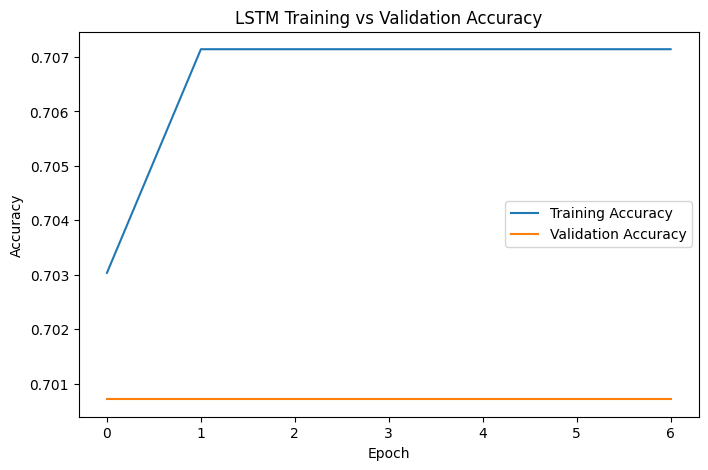

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("LSTM Training vs Validation Accuracy")

plt.legend()

plt.show()

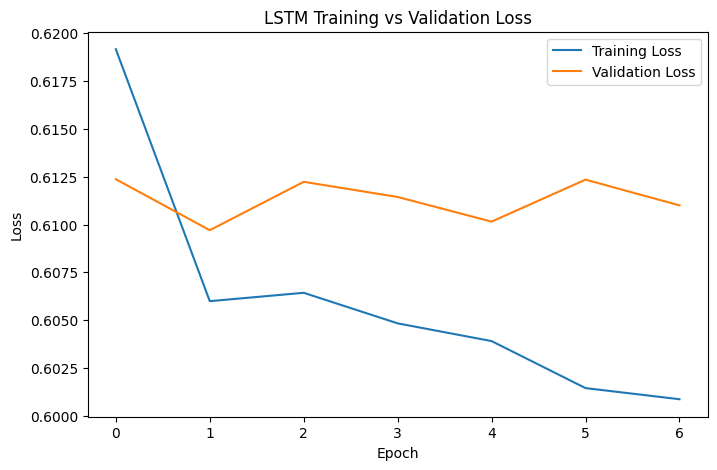

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("LSTM Training vs Validation Loss")

plt.legend()

plt.show()

## Evaluate on the test set

In [39]:
test_loss, test_accuracy = model.evaluate(
    [
        X_concept_test,
        X_numeric_test
    ],
    y_test,
    verbose=0
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Test Loss: 0.6048
Test Accuracy: 0.7065


In [40]:
y_probability = model.predict(
    [
        X_concept_test,
        X_numeric_test
    ],
    verbose=0
).ravel()

y_pred = (
    y_probability >= 0.5
).astype(int)

## Calculate complete metrics

In [41]:
lstm_accuracy = accuracy_score(
    y_test,
    y_pred
)

lstm_precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

lstm_recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

lstm_f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

lstm_roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("========== LSTM RESULTS ==========")

print(
    "Accuracy :",
    round(lstm_accuracy, 4)
)

print(
    "Precision:",
    round(lstm_precision, 4)
)

print(
    "Recall   :",
    round(lstm_recall, 4)
)

print(
    "F1 Score :",
    round(lstm_f1, 4)
)

print(
    "ROC-AUC  :",
    round(lstm_roc_auc, 4)
)

========== LSTM RESULTS ==========
Accuracy : 0.7065
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.526


In [42]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Incorrect",
            "Correct"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

   Incorrect       0.71      1.00      0.83      1413
     Correct       0.00      0.00      0.00       587

    accuracy                           0.71      2000
   macro avg       0.35      0.50      0.41      2000
weighted avg       0.50      0.71      0.58      2000



In [43]:
cm_lstm = confusion_matrix(
    y_test,
    y_pred
)

print("LSTM Confusion Matrix:")
print(cm_lstm)

LSTM Confusion Matrix:
[[1413    0]
 [ 587    0]]


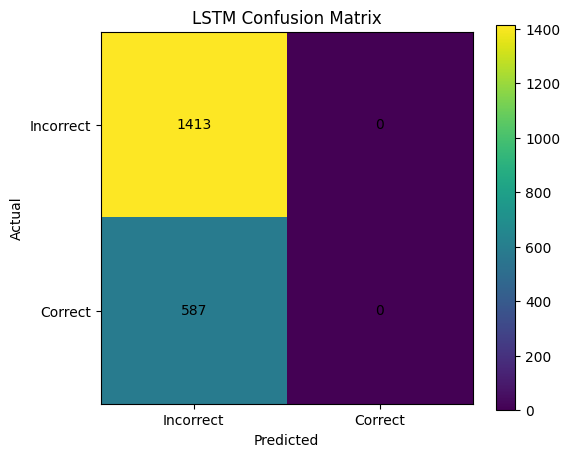

In [44]:
plt.figure(figsize=(6, 5))

plt.imshow(cm_lstm)

plt.title("LSTM Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Incorrect", "Correct"]
)

plt.yticks(
    [0, 1],
    ["Incorrect", "Correct"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_lstm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

In [45]:
model.save(
    "learntwin_lstm_model.keras"
)

print(
    "LSTM model saved successfully!"
)

LSTM model saved successfully!
